<a href="https://colab.research.google.com/github/Shraddha063/vfb-approx-multiplier-cosim/blob/main/notebooks/vfb_approx_multiplier_cosi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%bash
apt-get update
apt-get install -y iverilog gtkwave


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgt

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!iverilog -v


Icarus Verilog version 11.0 (stable) ()

Copyright 1998-2020 Stephen Williams

  This program is free software; you can redistribute it and/or modify
  it under the terms of the GNU General Public License as published by
  the Free Software Foundation; either version 2 of the License, or
  (at your option) any later version.

  This program is distributed in the hope that it will be useful,
  but WITHOUT ANY WARRANTY; without even the implied warranty of
  MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
  GNU General Public License for more details.

  You should have received a copy of the GNU General Public License along
  with this program; if not, write to the Free Software Foundation, Inc.,
  51 Franklin Street, Fifth Floor, Boston, MA 02110-1301, USA.

iverilog: no source files.

Usage: iverilog [-EiSuvV] [-B base] [-c cmdfile|-f cmdfile]
                [-g1995|-g2001|-g2005|-g2005-sv|-g2009|-g2012] [-g<feature>]
                [-D macro[=defn]] [-I includedir] [-

In [ ]:
%%writefile approx_multiplier.v
`timescale 1ns / 1ps

module hybrid_dadda_8x8(
    input  [7:0] A,
    input  [7:0] B,
    output [15:0] Product
);

// PARTIAL PRODUCTS WITH LOW-POWER GATING
wire pp[7:0][7:0];
genvar i,j;

generate
    for(i=0;i<8;i=i+1) begin
        for(j=0;j<8;j=j+1) begin
            // Approximate low significance PP region
            if(i+j <= 3)
                assign pp[i][j] = (A[i] & B[j]) & (A[i] | B[j]);
            // Exact higher region
            else
                assign pp[i][j] = A[i] & B[j];
        end
    end
endgenerate

// COLUMN 0
assign Product[0] = pp[0][0];

// COLUMN 1
wire s11,c11;
half_adder HA11(.A(pp[0][1]), .B(pp[1][0]), .Sum(s11), .Carry(c11));
assign Product[1] = s11;

// COLUMN 2
wire s21,c21;
wire en21;
assign en21 = pp[0][2] | pp[1][1] | pp[2][0] | c11;

approx_4_2_compressor AC21(
    .A(en21 ? pp[0][2] : 1'b0),
    .B(en21 ? pp[1][1] : 1'b0),
    .C(en21 ? pp[2][0] : 1'b0),
    .D(en21 ? c11      : 1'b0),
    .Sum(s21), .Carry(c21)
);
assign Product[2] = s21;

// COLUMN 3
wire s31,c31, s32,c32, s33,c33;
wire en31;
assign en31 = pp[0][3] | pp[1][2] | pp[2][1];

approx_4_2_compressor AC31(
    .A(en31 ? pp[0][3] : 1'b0),
    .B(en31 ? pp[1][2] : 1'b0),
    .C(en31 ? pp[2][1] : 1'b0),
    .D(1'b0),
    .Sum(s31), .Carry(c31)
);
half_adder HA31(.A(pp[3][0]), .B(c21), .Sum(s32), .Carry(c32));
approx_4_2_compressor AC32(.A(s31), .B(s32), .C(1'b0), .D(1'b0), .Sum(s33), .Carry(c33));
assign Product[3] = s33;

// COLUMN 4
wire s41,c41, s42,c42, s43,c43;
approx_4_2_compressor AC41(.A(pp[0][4]), .B(pp[1][3]), .C(pp[2][2]), .D(pp[3][1]), .Sum(s41), .Carry(c41));
approx_4_2_compressor AC42(.A(pp[4][0]), .B(c31), .C(c32), .D(1'b0), .Sum(s42), .Carry(c42));
approx_4_2_compressor AC43(.A(s41), .B(s42), .C(c33), .D(1'b0), .Sum(s43), .Carry(c43));
assign Product[4] = s43;

// COLUMN 5
wire s51,c51, s52,c52, s53,c53, s54,c54;
approx_4_2_compressor AC51(.A(pp[0][5]), .B(pp[1][4]), .C(pp[2][3]), .D(1'b0), .Sum(s51), .Carry(c51));
approx_4_2_compressor AC52(.A(pp[3][2]), .B(pp[4][1]), .C(pp[5][0]), .D(1'b0), .Sum(s52), .Carry(c52));
approx_4_2_compressor AC53(.A(s51), .B(s52), .C(c41), .D(1'b0), .Sum(s53), .Carry(c53));
approx_4_2_compressor AC54(.A(s53), .B(c42), .C(c43), .D(1'b0), .Sum(s54), .Carry(c54));
assign Product[5] = s54;

// COLUMN 6
wire s61,c61, s62,c62, s63,c63, s64,c64, s65,c65;
approx_4_2_compressor AC61(.A(pp[0][6]), .B(pp[1][5]), .C(pp[2][4]), .D(1'b0), .Sum(s61), .Carry(c61));
approx_4_2_compressor AC62(.A(pp[3][3]), .B(pp[4][2]), .C(pp[5][1]), .D(1'b0), .Sum(s62), .Carry(c62));
approx_4_2_compressor AC63(.A(pp[6][0]), .B(c51), .C(c52), .D(1'b0), .Sum(s63), .Carry(c63));
approx_4_2_compressor AC64(.A(s61), .B(s62), .C(s63), .D(1'b0), .Sum(s64), .Carry(c64));
full_adder FA65(.A(s64), .B(c53), .Cin(c54), .Sum(s65), .Cout(c65));
assign Product[6] = s65;

// MANUAL EXACT UPPER REGION
wire [15:0] exact_mult = A * B;
assign Product[7]  = exact_mult[7];
assign Product[8]  = exact_mult[8];
assign Product[9]  = exact_mult[9];
assign Product[10] = exact_mult[10];
assign Product[11] = exact_mult[11];
assign Product[12] = exact_mult[12];
assign Product[13] = exact_mult[13];
assign Product[14] = exact_mult[14];
assign Product[15] = exact_mult[15];

endmodule

module approx_4_2_compressor(
    input A, B, C, D,
    output Sum, Carry
);
wire ab, cd, ab_or, cd_or, Y0, Y1, Y2, correction, approx_enable, carry_en;

assign ab = A & B;
assign cd = C & D;
assign ab_or = A | B;
assign cd_or = C | D;

assign approx_enable = ab_or | cd_or;
assign Y0 = approx_enable;
assign Y1 = ab_or & cd_or;
assign Y2 = approx_enable ? (ab | cd) : 1'b0;

assign correction = (ab & ~cd_or) | (cd & ~ab_or);
assign carry_en = Y1 | Y2;

assign Sum = approx_enable ? ((~Y1 | Y2) & ~correction) : 1'b0;
assign Carry = approx_enable ? carry_en : 1'b0;
endmodule

module half_adder(
    input A, B,
    output Sum, Carry
);
    assign Sum   = A ^ B;
    assign Carry = A & B;
endmodule

module full_adder(
    input A, B, Cin,
    output Sum, Cout
);
wire ab, AxorB;
assign ab = A & B;
assign AxorB = A ^ B;
assign Sum = AxorB ^ Cin;
assign Cout = Cin ? (ab | AxorB) : ab;
endmodule

Overwriting approx_multiplier.v


In [ ]:
%%writefile tb_runner.v
`timescale 1ns / 1ps

module tb_runner;
    reg [7:0] A;
    reg [7:0] B;
    wire [15:0] Product;

    integer file_in, file_out, status;

    hybrid_dadda_8x8 uut (
        .A(A),
        .B(B),
        .Product(Product)
    );

    initial begin
        file_in = $fopen("input_pairs.txt", "r");
        file_out = $fopen("hardware_outputs.txt", "w");

        while (!$feof(file_in)) begin
            status = $fscanf(file_in, "%d %d\n", A, B);
            #10;
            $fdisplay(file_out, "%d", Product);
        end

        $fclose(file_in);
        $fclose(file_out);
        $finish;
    end
endmodule

Overwriting tb_runner.v


Simulating Verilog Hybrid Dadda Multiplier across Filter Bank channels...
Co-simulation complete!


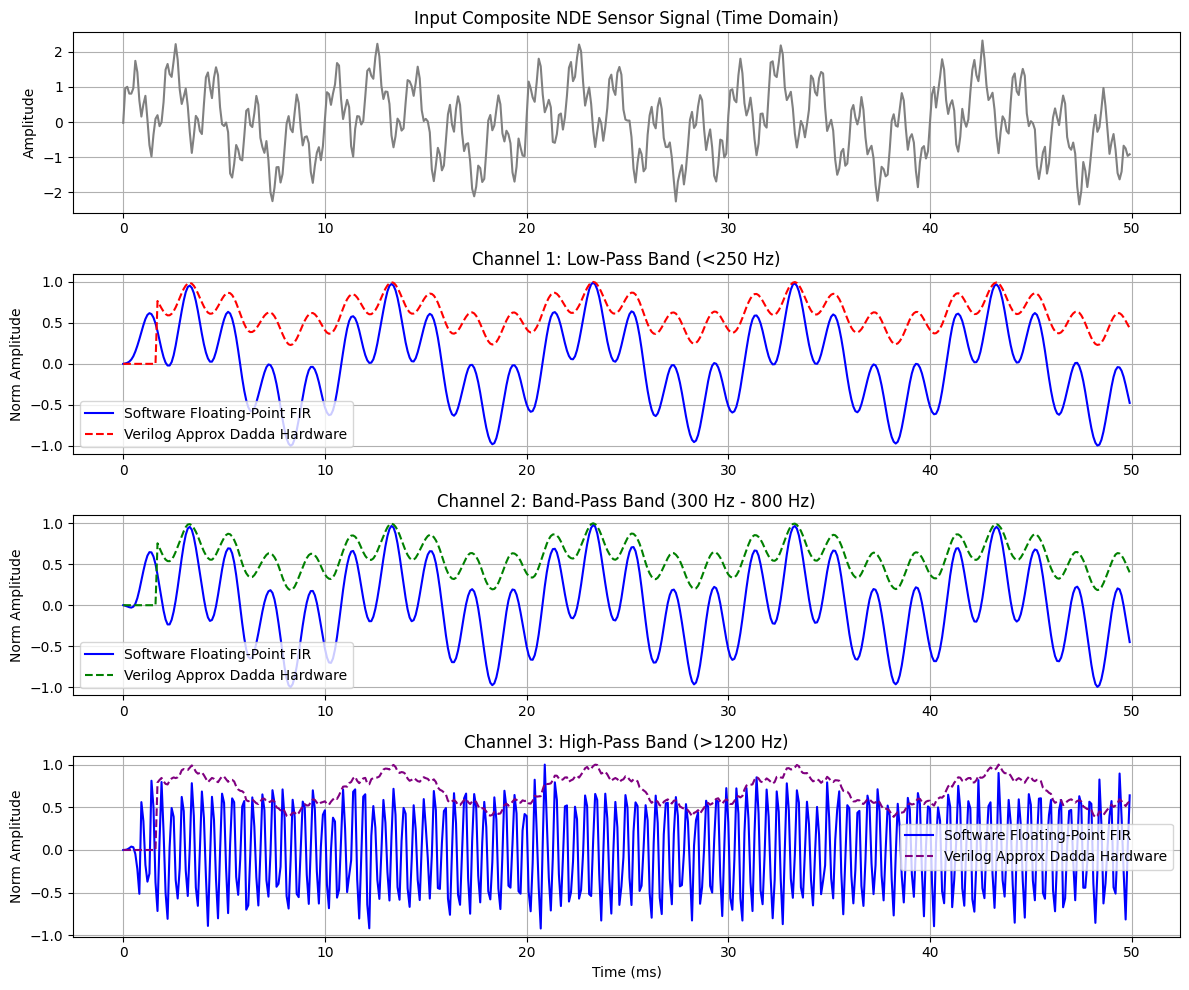

In [ ]:
import numpy as np
import scipy.signal as signal
import subprocess
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. GENERATE NDE SENSOR INPUT & FILTER BANK COEFFICIENTS
# ---------------------------------------------------------
fs = 10000  # Sampling frequency: 10 kHz
t = np.linspace(0, 0.05, int(fs * 0.05), endpoint=False)

# Multi-frequency NDE Sensor Signal: Low (100Hz), Mid (500Hz), High (2000Hz)
sig_100hz  = 0.8 * np.sin(2 * np.pi * 100 * t)
sig_500hz  = 1.0 * np.sin(2 * np.pi * 500 * t)
sig_2000hz = 0.5 * np.sin(2 * np.pi * 2000 * t)
raw_sensor_signal = sig_100hz + sig_500hz + sig_2000hz + np.random.normal(0, 0.1, size=len(t))

# FIR Filter Bank Design (Low-pass, Band-pass, High-pass)
num_taps = 17
b_lp = signal.firwin(num_taps, 250, fs=fs)
b_bp = signal.firwin(num_taps, [300, 800], pass_zero=False, fs=fs)
b_hp = signal.firwin(num_taps, 1200, pass_zero=False, fs=fs)

# Quantize signal and coefficients to 8-bit unsigned scale (0 to 255)
def quantize_8bit(data):
    scaled = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8) * 255
    return np.clip(scaled, 0, 255).astype(np.uint8)

q_signal = quantize_8bit(raw_sensor_signal)

# ---------------------------------------------------------
# 2. VERILOG HARDWARE CO-SIMULATION FUNCTION
# ---------------------------------------------------------
# Compile Verilog HDL code using Icarus Verilog
subprocess.run(["iverilog", "-o", "vfb_sim.vvp", "approx_multiplier.v", "tb_runner.v"], check=True)

def run_verilog_filter_channel(b_coeffs, input_bytes):
    q_b = quantize_8bit(b_coeffs)
    n_samples = len(input_bytes)

    # Create input vector file for Verilog MAC operations
    input_pairs = []
    for n in range(num_taps, n_samples):
        for k in range(num_taps):
            input_pairs.append((q_b[k], input_bytes[n - k]))

    with open("input_pairs.txt", "w") as f:
        for val_a, val_b in input_pairs:
            f.write(f"{val_a} {val_b}\n")

    # Execute Verilog hardware simulation
    subprocess.run(["vvp", "vfb_sim.vvp"], check=True)

    # Read back hardware computed products
    with open("hardware_outputs.txt", "r") as f:
        raw_products = [int(line.strip()) for line in f.readlines() if line.strip()]

    # Accumulate MAC outputs
    filtered_out = np.zeros(n_samples)
    idx = 0
    for n in range(num_taps, n_samples):
        mac_sum = 0
        for k in range(num_taps):
            mac_sum += raw_products[idx]
            idx += 1
        filtered_out[n] = mac_sum

    return filtered_out

print("Simulating Verilog Hybrid Dadda Multiplier across Filter Bank channels...")
hw_lp = run_verilog_filter_channel(b_lp, q_signal)
hw_bp = run_verilog_filter_channel(b_bp, q_signal)
hw_hp = run_verilog_filter_channel(b_hp, q_signal)

# Floating point baseline filters for comparison
sw_lp = signal.lfilter(b_lp, 1.0, raw_sensor_signal)
sw_bp = signal.lfilter(b_bp, 1.0, raw_sensor_signal)
sw_hp = signal.lfilter(b_hp, 1.0, raw_sensor_signal)

# Normalize for visual overlay comparison
def norm(x): return x / (np.max(np.abs(x)) + 1e-8)

print("Co-simulation complete!")

# ---------------------------------------------------------
# 3. PLOT AND SAVE VISUALIZATION FOR GITHUB
# ---------------------------------------------------------
fig, axs = plt.subplots(4, 1, figsize=(12, 10))

axs[0].plot(t * 1000, raw_sensor_signal, color='gray')
axs[0].set_title("Input Composite NDE Sensor Signal (Time Domain)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)

axs[1].plot(t * 1000, norm(sw_lp), color='blue', label='Software Floating-Point FIR')
axs[1].plot(t * 1000, norm(hw_lp), color='red', linestyle='--', label='Verilog Approx Dadda Hardware')
axs[1].set_title("Channel 1: Low-Pass Band (<250 Hz)")
axs[1].set_ylabel("Norm Amplitude")
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t * 1000, norm(sw_bp), color='blue', label='Software Floating-Point FIR')
axs[2].plot(t * 1000, norm(hw_bp), color='green', linestyle='--', label='Verilog Approx Dadda Hardware')
axs[2].set_title("Channel 2: Band-Pass Band (300 Hz - 800 Hz)")
axs[2].set_ylabel("Norm Amplitude")
axs[2].legend()
axs[2].grid(True)

axs[3].plot(t * 1000, norm(sw_hp), color='blue', label='Software Floating-Point FIR')
axs[3].plot(t * 1000, norm(hw_hp), color='purple', linestyle='--', label='Verilog Approx Dadda Hardware')
axs[3].set_title("Channel 3: High-Pass Band (>1200 Hz)")
axs[3].set_xlabel("Time (ms)")
axs[3].set_ylabel("Norm Amplitude")
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.savefig("vfb_hardware_cosim_output.png", dpi=300)
plt.show()